In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Online Sales Data.csv to Online Sales Data.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Online Sales Data.csv")
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [ ]:
df.shape

(240, 9)

In [ ]:
df.columns

Index(['Transaction ID', 'Date', 'Product Category', 'Product Name',
       'Units Sold', 'Unit Price', 'Total Revenue', 'Region',
       'Payment Method'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


In [ ]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful date columns
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

# Check updated dataframe
df.head()

Duplicate rows: 0


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Month,Month_Name,Year
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card,1,January,2024
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,1,January,2024
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,1,January,2024
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card,1,January,2024
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal,1,January,2024


In [ ]:
print("Total Transactions:", len(df))
print("Total Revenue:", df['Total Revenue'].sum())
print("Total Units Sold:", df['Units Sold'].sum())
print("Unique Products:", df['Product Name'].nunique())
print("Unique Categories:", df['Product Category'].nunique())

Total Transactions: 240
Total Revenue: 80567.84999999999
Total Units Sold: 518
Unique Products: 232
Unique Categories: 6


In [ ]:
top_products = df.groupby('Product Name')['Units Sold'].sum().sort_values(ascending=False)

print(top_products.head(10))

Product Name
Hanes ComfortSoft T-Shirt                  10
The Catcher in the Rye by J.D. Salinger     7
Nike Air Force 1                            6
Gap Essential Crewneck T-Shirt              6
Yeti Rambler Tumbler                        6
Spalding NBA Street Basketball              6
Adidas 3-Stripes Shorts                     5
Calvin Klein Boxer Briefs                   5
Titleist Pro V1 Golf Balls                  5
Under Armour HeatGear T-Shirt               5
Name: Units Sold, dtype: int64


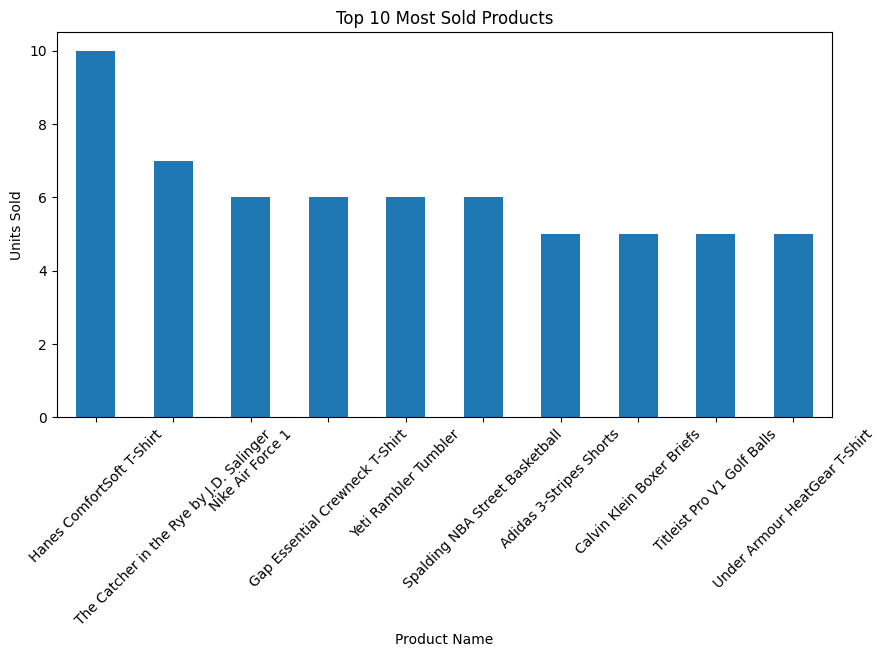

In [ ]:
import matplotlib.pyplot as plt

top_products.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Most Sold Products")
plt.xlabel("Product Name")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

In [ ]:
category_revenue = df.groupby('Product Category')['Total Revenue'].sum().sort_values(ascending=False)

print(category_revenue)

Product Category
Electronics        34982.41
Home Appliances    18646.16
Sports             14326.52
Clothing            8128.93
Beauty Products     2621.90
Books               1861.93
Name: Total Revenue, dtype: float64


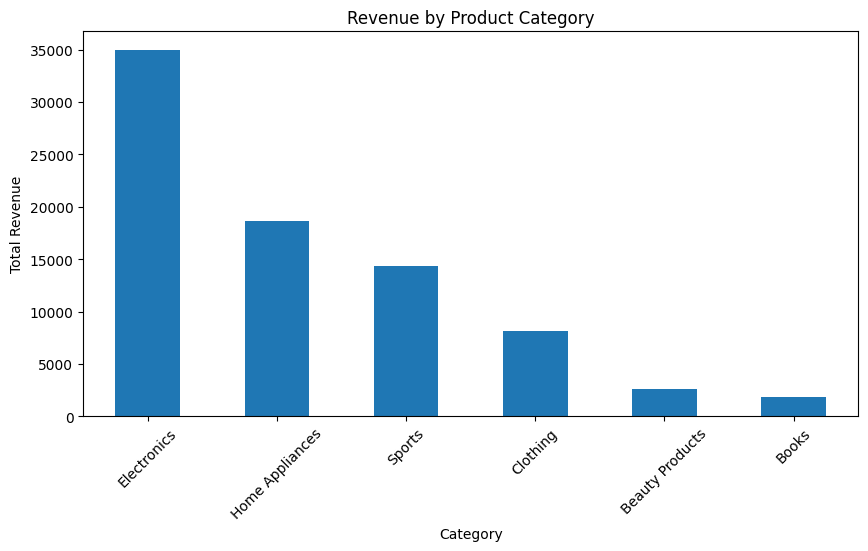

In [ ]:
category_revenue.plot(kind='bar', figsize=(10,5))
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
monthly_revenue = df.groupby(['Month', 'Month_Name'])['Total Revenue'].sum().reset_index()

monthly_revenue

,Month,Month_Name,Total Revenue
0,1,January,14548.32
1,2,February,10803.37
2,3,March,12849.24
3,4,April,12451.69
4,5,May,8455.49
5,6,June,7384.55
6,7,July,6797.08
7,8,August,7278.11


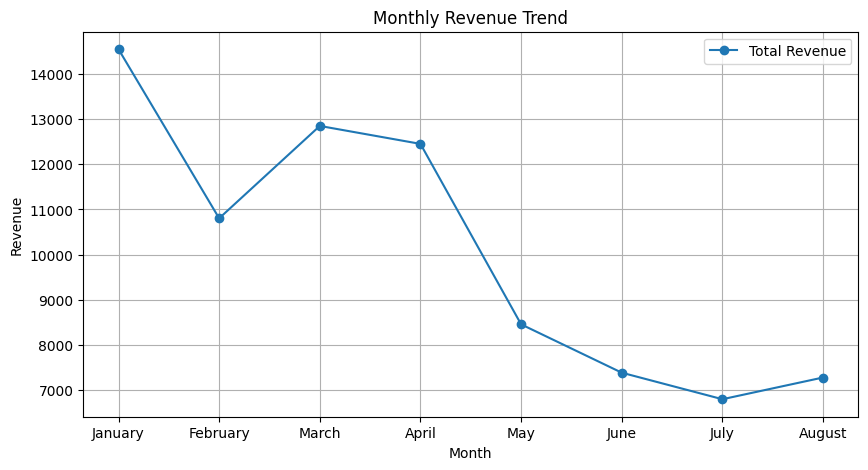

In [ ]:
monthly_revenue.plot(x='Month_Name', y='Total Revenue', kind='line', marker='o', figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [ ]:
region_sales = df.groupby('Region')['Total Revenue'].sum().sort_values(ascending=False)

print(region_sales)

Region
North America    36844.34
Asia             22455.45
Europe           21268.06
Name: Total Revenue, dtype: float64


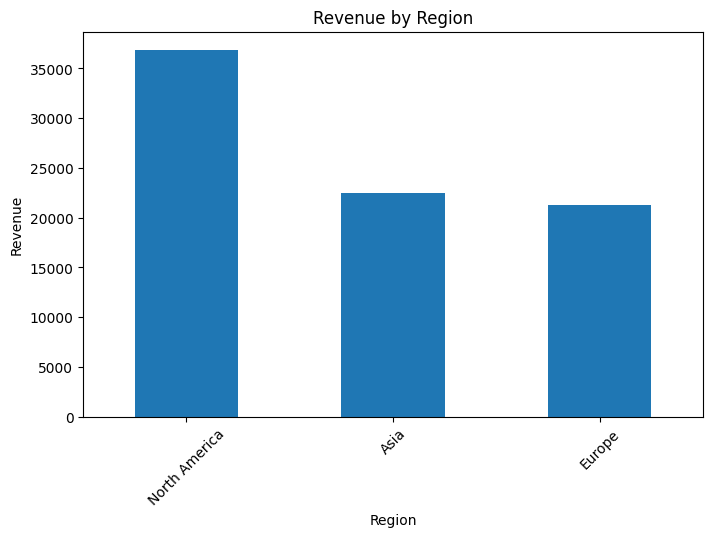

In [ ]:
region_sales.plot(kind='bar', figsize=(8,5))
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
payment_analysis = df.groupby('Payment Method')['Total Revenue'].sum()

print(payment_analysis)

Payment Method
Credit Card    51170.86
Debit Card      8128.93
PayPal         21268.06
Name: Total Revenue, dtype: float64


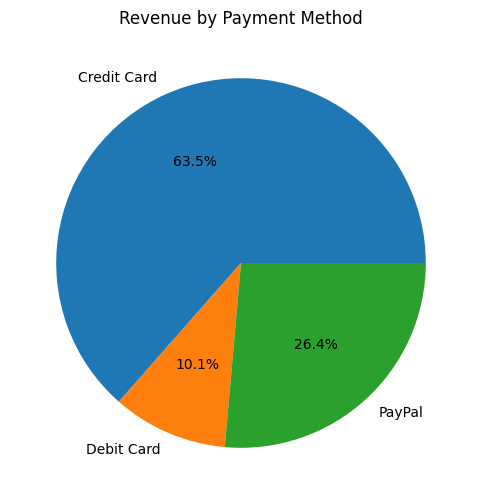

In [ ]:
payment_analysis.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Revenue by Payment Method")
plt.ylabel("")
plt.show()

In [ ]:
pivot_table = pd.pivot_table(
    df,
    values='Total Revenue',
    index='Product Category',
    columns='Month_Name',
    aggfunc='sum'
)

pivot_table

Month_Name,April,August,February,January,July,June,March,May
Product Category,,,,,,,,
Beauty Products,201.48,170.70,331.98,699.95,464.00,209.49,417.00,127.30
Books,220.85,192.87,422.91,308.86,163.88,149.86,252.83,149.87
Clothing,769.80,769.91,1284.81,1789.84,1095.48,579.45,1009.76,829.88
Electronics,6709.91,3066.96,2899.88,7999.90,2006.97,3599.93,4499.90,4198.96
Home Appliances,1989.85,1668.96,2869.92,2169.94,1417.87,1479.89,5059.91,1989.82
Sports,2559.80,1408.71,2993.87,1579.83,1648.88,1365.93,1609.84,1159.66


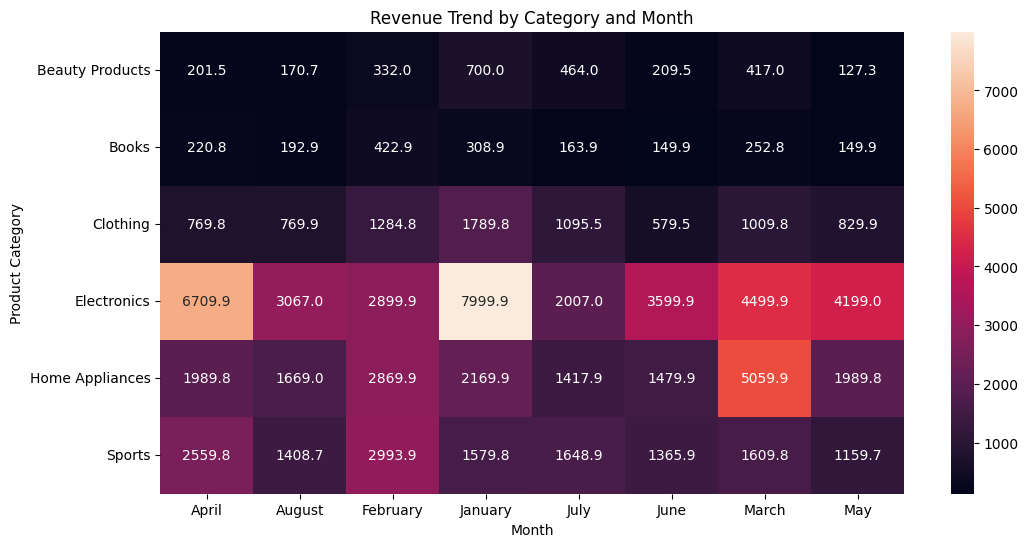

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, annot=True, fmt=".1f")
plt.title("Revenue Trend by Category and Month")
plt.xlabel("Month")
plt.ylabel("Product Category")
plt.show()